Load Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umuttuygurr/e-commerce-fraud-detection-dataset")

print("Path to dataset files:", path)

import pandas as pd
data = pd.read_csv(path + "/transactions.csv")
data.head()

Using Colab cache for faster access to the 'e-commerce-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/e-commerce-fraud-detection-dataset


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [ ]:
data.shape

(299695, 17)

In [ ]:
print(data.columns)

Index(['transaction_id', 'user_id', 'account_age_days',
       'total_transactions_user', 'avg_amount_user', 'amount', 'country',
       'bin_country', 'channel', 'merchant_category', 'promo_used',
       'avs_match', 'cvv_result', 'three_ds_flag', 'transaction_time',
       'shipping_distance_km', 'is_fraud'],
      dtype='object')


In [ ]:
data.describe()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000


In [ ]:
print(data.dtypes)

transaction_id               int64
user_id                      int64
account_age_days             int64
total_transactions_user      int64
avg_amount_user            float64
amount                     float64
country                     object
bin_country                 object
channel                     object
merchant_category           object
promo_used                   int64
avs_match                    int64
cvv_result                   int64
three_ds_flag                int64
transaction_time            object
shipping_distance_km       float64
is_fraud                     int64
dtype: object


### change data types
wrong data type of cvv result, promo_used, avs_match, three_ds_match, is_fraud

In [ ]:
data['cvv_result'] = data['cvv_result'].astype(object)
data['promo_used'] = data['promo_used'].astype(object)
data['avs_match'] = data['avs_match'].astype(object)
data['is_fraud'] = data['is_fraud'].astype(object)
data['three_ds_flag'] = data['three_ds_flag'].astype(object)
data.dtypes

,0
transaction_id,int64
user_id,int64
account_age_days,int64
total_transactions_user,int64
avg_amount_user,float64
amount,float64
country,object
bin_country,object
channel,object
merchant_category,object


### Count numerical and categorical columns

In [ ]:
quan_var = data.select_dtypes(include='number').columns.tolist()
print(f'There are {len(quan_var)} quantitative columns.')
qual_var = data.select_dtypes(exclude='number').columns.tolist()
print(f'There are {len(qual_var)} qualitative columns.')

There are 7 quantitative columns.
There are 10 qualitative columns.


Predicting a qualitative column 'is_fraud' (whether fraud or not) is considered Classification problem because we are trying to predict a qualitative column type.

### Is the dataset well-balanced?

In [ ]:
# Is the dataset well-balanced?
data['is_fraud'].value_counts(normalize=True)

,proportion
is_fraud,
0,0.977938
1,0.022062


### Handle imbalance data by calculating class weight

In [ ]:
# # handle imbalance data
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np
# weights = compute_class_weight('balanced', classes=np.array([0,1]), y=data['is_fraud'])
# print(weights)

### Find missing value

In [ ]:
# missing values encoded as 'nan'
data.isna().sum().sum()

np.int64(0)

### Find duplicating value

In [ ]:
#duplication
print(f'There are {int(data.duplicated().sum())} duplicated rows in the dataset.')
data.drop_duplicates(inplace=True) # drop duplication and modify the data directly (inplace=true)
data.duplicated().sum() # number of duplicated rows


There are 0 duplicated rows in the dataset.


np.int64(0)

### UNIVARIATE ANALYSIS
### Display boxplots of numerical features

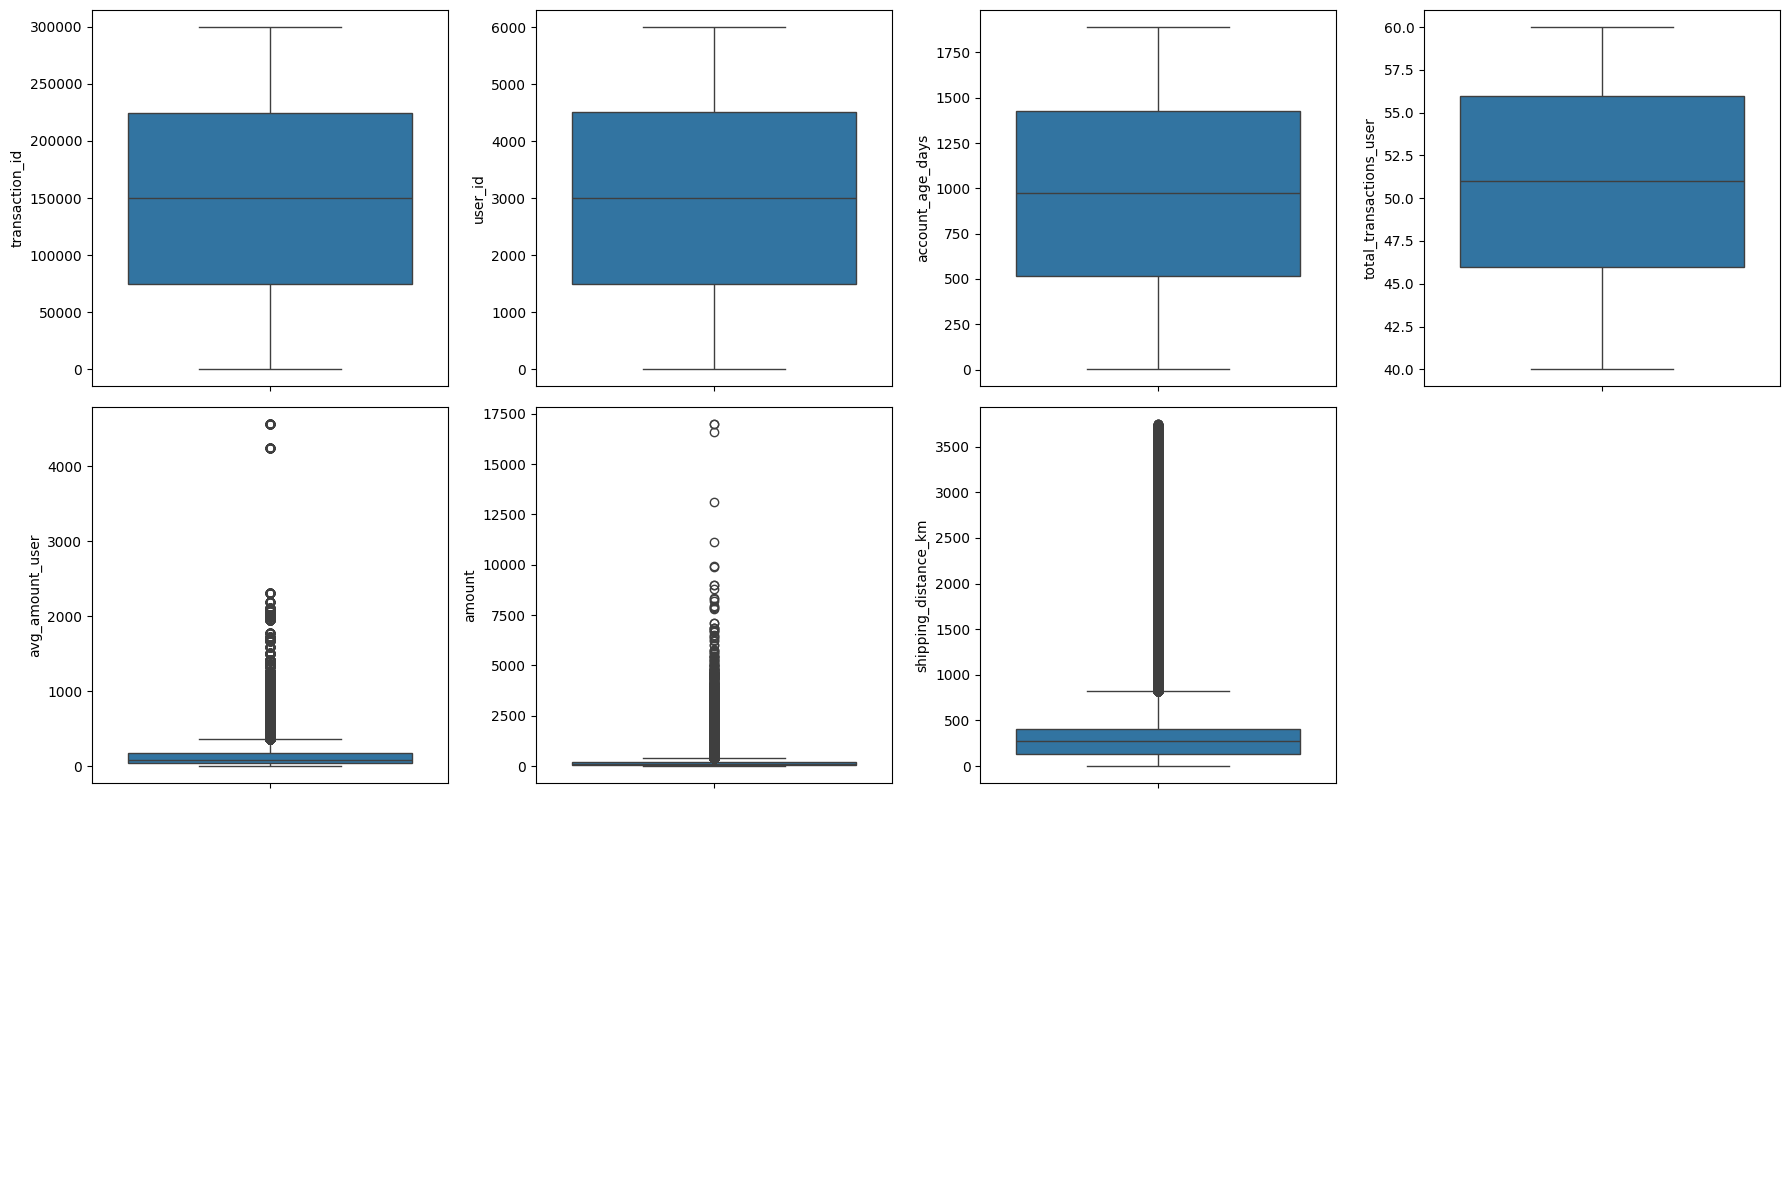

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get numerical columns
numerical_cols = data.select_dtypes(include='number').columns
num_plots = len(numerical_cols)

# Adjust subplot grid to accommodate all numerical columns (10 columns total)
# A 3x4 grid will be used to ensure enough space.
fig, ax = plt.subplots(3, 4, figsize=(18, 12)) # Changed to 3 rows, 4 columns
ax = ax.flatten() # Flatten the 3x4 array of axes for easier iteration

for i, va in enumerate(numerical_cols):
  sns.boxplot(data, y=va, ax=ax[i])

# Turn off any unused subplots
for j in range(num_plots, len(ax)):
    ax[j].axis('off')

plt.tight_layout()

### Display barplots of categorical features

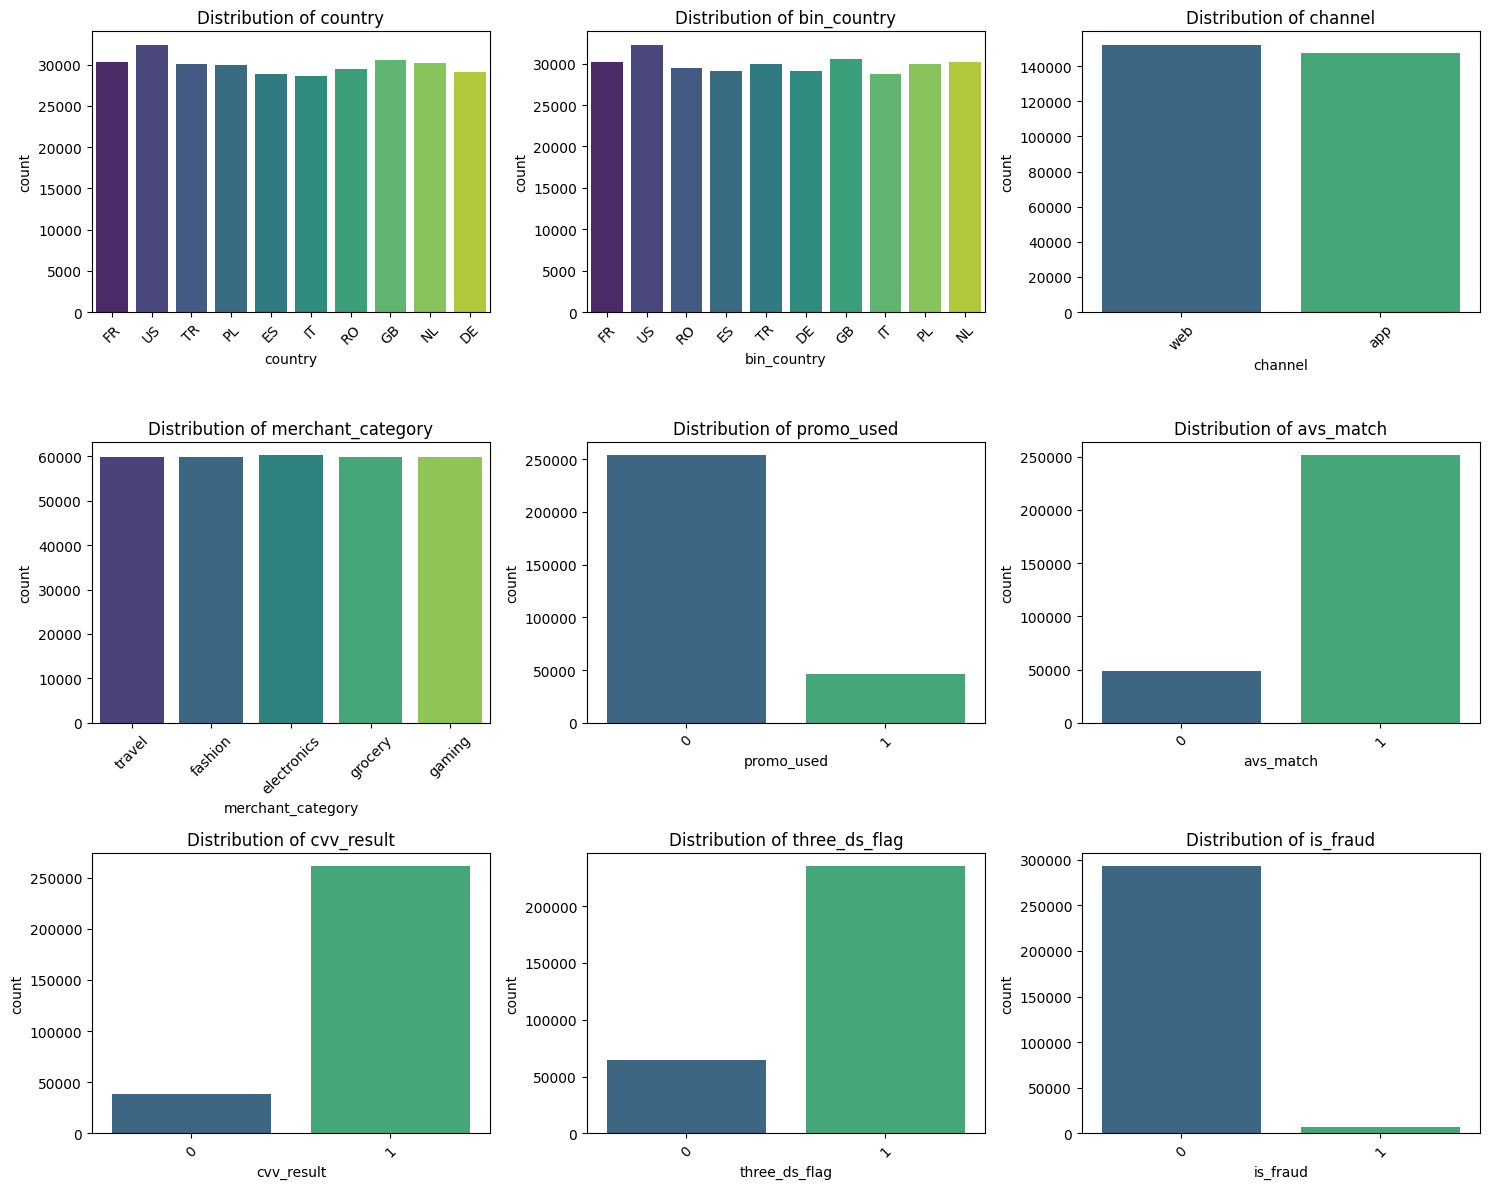

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get qualitative (object type) columns, excluding 'transaction_time' as it was converted to datetime
qualitative_cols = data.select_dtypes(include='object').columns.tolist()
# Exclude 'transaction_time' if it's still in object type after conversion
if 'transaction_time' in qualitative_cols:
    qualitative_cols.remove('transaction_time')

num_plots = len(qualitative_cols)

# Determine grid size. For example, if 7 columns, a 3x3 grid (9 plots) would work.
# Calculate rows and columns dynamically
num_cols_per_row = 3 # You can adjust this for better visualization
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

fig, ax = plt.subplots(num_rows, num_cols_per_row, figsize=(5 * num_cols_per_row, 4 * num_rows))
ax = ax.flatten() # Flatten the array of axes for easier iteration

for i, col in enumerate(qualitative_cols):
  sns.countplot(data=data, x=col, hue=col, ax=ax[i], palette='viridis', legend=False)
  ax[i].set_title(f'Distribution of {col}')
  ax[i].tick_params(axis='x', rotation=45)

# Turn off any unused subplots
for j in range(num_plots, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
plt.show()

### BIVARIATE ANALYSIS
### Display conditional boxplots of numerical features

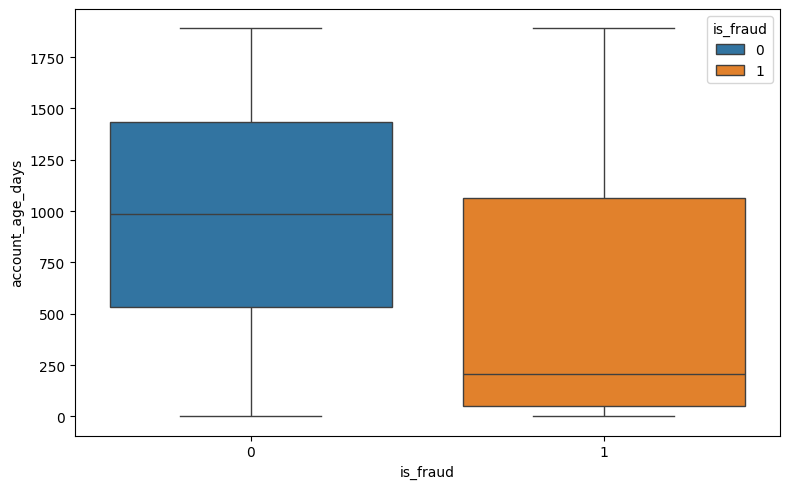

In [ ]:
_, axs = plt.subplots(1, 1, figsize=(8, 5))
sns.boxplot(data=data, x="is_fraud", y="account_age_days", hue="is_fraud", ax=axs)
plt.tight_layout()
plt.show()

new user accounts tend to be fraudulent.

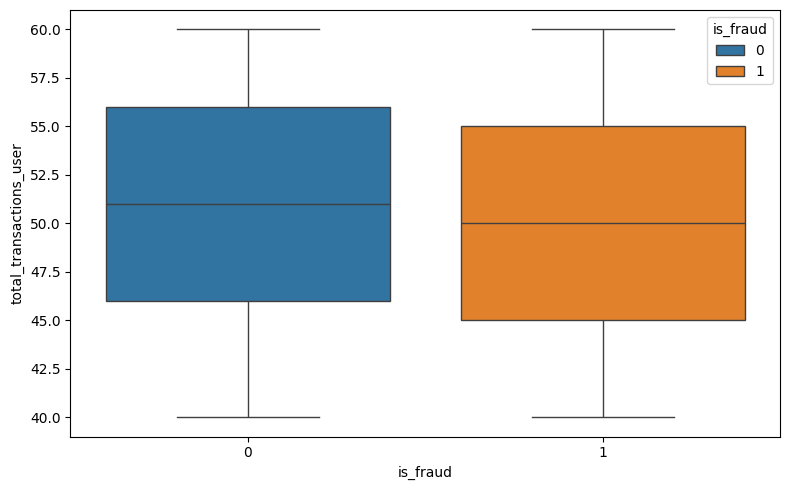

In [ ]:
_, axs = plt.subplots(1, 1, figsize=(8, 5))
sns.boxplot(data=data, x="is_fraud", y="total_transactions_user", hue="is_fraud", ax=axs)
plt.tight_layout()
plt.show()

fraud users have fewer transactions

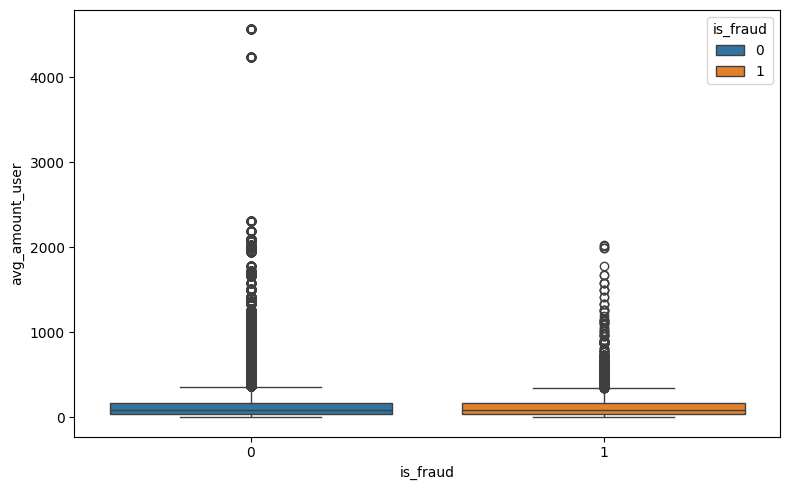

In [ ]:
_, axs = plt.subplots(1, 1, figsize=(8, 5))
sns.boxplot(data=data, x="is_fraud", y="avg_amount_user", hue="is_fraud", ax=axs)
plt.tight_layout()
plt.show()

There are many outliers and small/same distributions in avg_amount_users

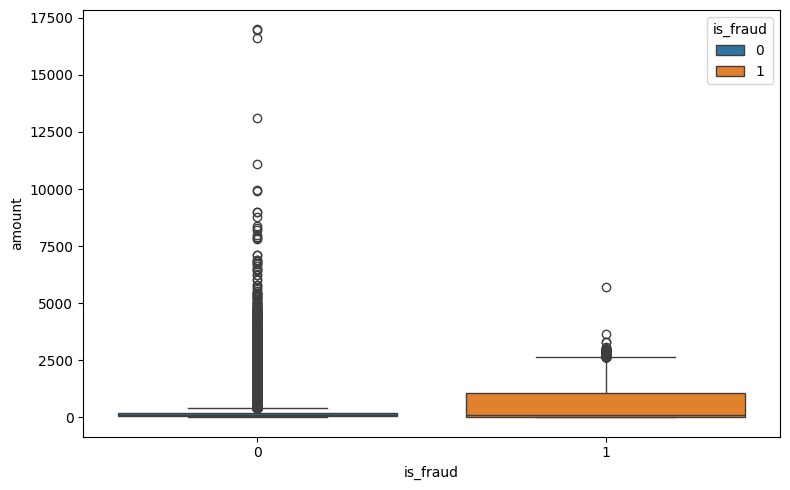

In [ ]:
_, axs = plt.subplots(1, 1, figsize=(8, 5))
sns.boxplot(data=data, x="is_fraud", y="amount", hue="is_fraud", ax=axs)
plt.tight_layout()
plt.show()

fraudulent transactions tend to have higher amount.

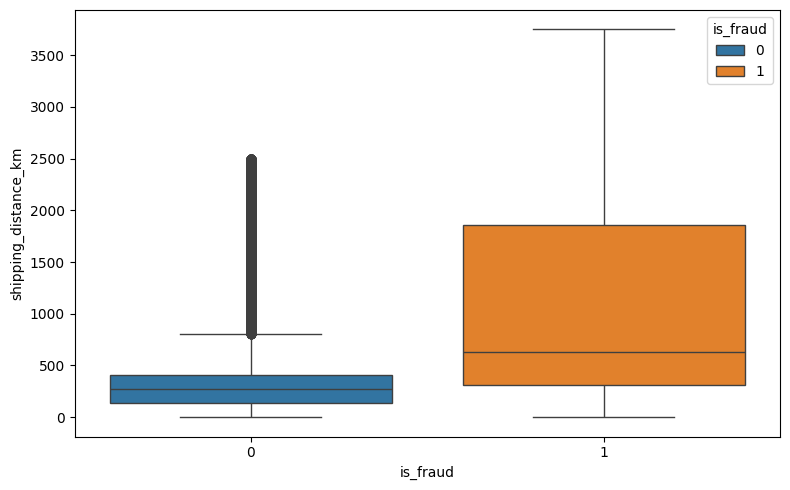

In [ ]:
_, axs = plt.subplots(1, 1, figsize=(8, 5))
sns.boxplot(data=data, x="is_fraud", y="shipping_distance_km", hue="is_fraud", ax=axs)
plt.tight_layout()
plt.show()

fraud = larger distance

strong predictors: amount, distance, acc age days

### pair plot

In [ ]:
# ''' pair plot'''
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Select the numerical columns that are relevant for pair plots, plus the target variable
# # Exclude identifiers like 'transaction_id', 'user_id'
# numerical_features_for_pairplot = [
#     'account_age_days',
#     'total_transactions_user',
#     'avg_amount_user',
#     'amount',
#     'shipping_distance_km',
#     'is_fraud'
# ]

# # Create a subset DataFrame for the pairplot
# df_for_pairplot = data[numerical_features_for_pairplot]

# # Generate pair plots with 'is_fraud' as hue
# sns.pairplot(df_for_pairplot, hue='is_fraud', diag_kind='kde')
# plt.suptitle('Pair Plots of Numerical Features by Fraud Status', y=1.02) # Adjust suptitle position
# plt.show()

Display countplot of categorical features

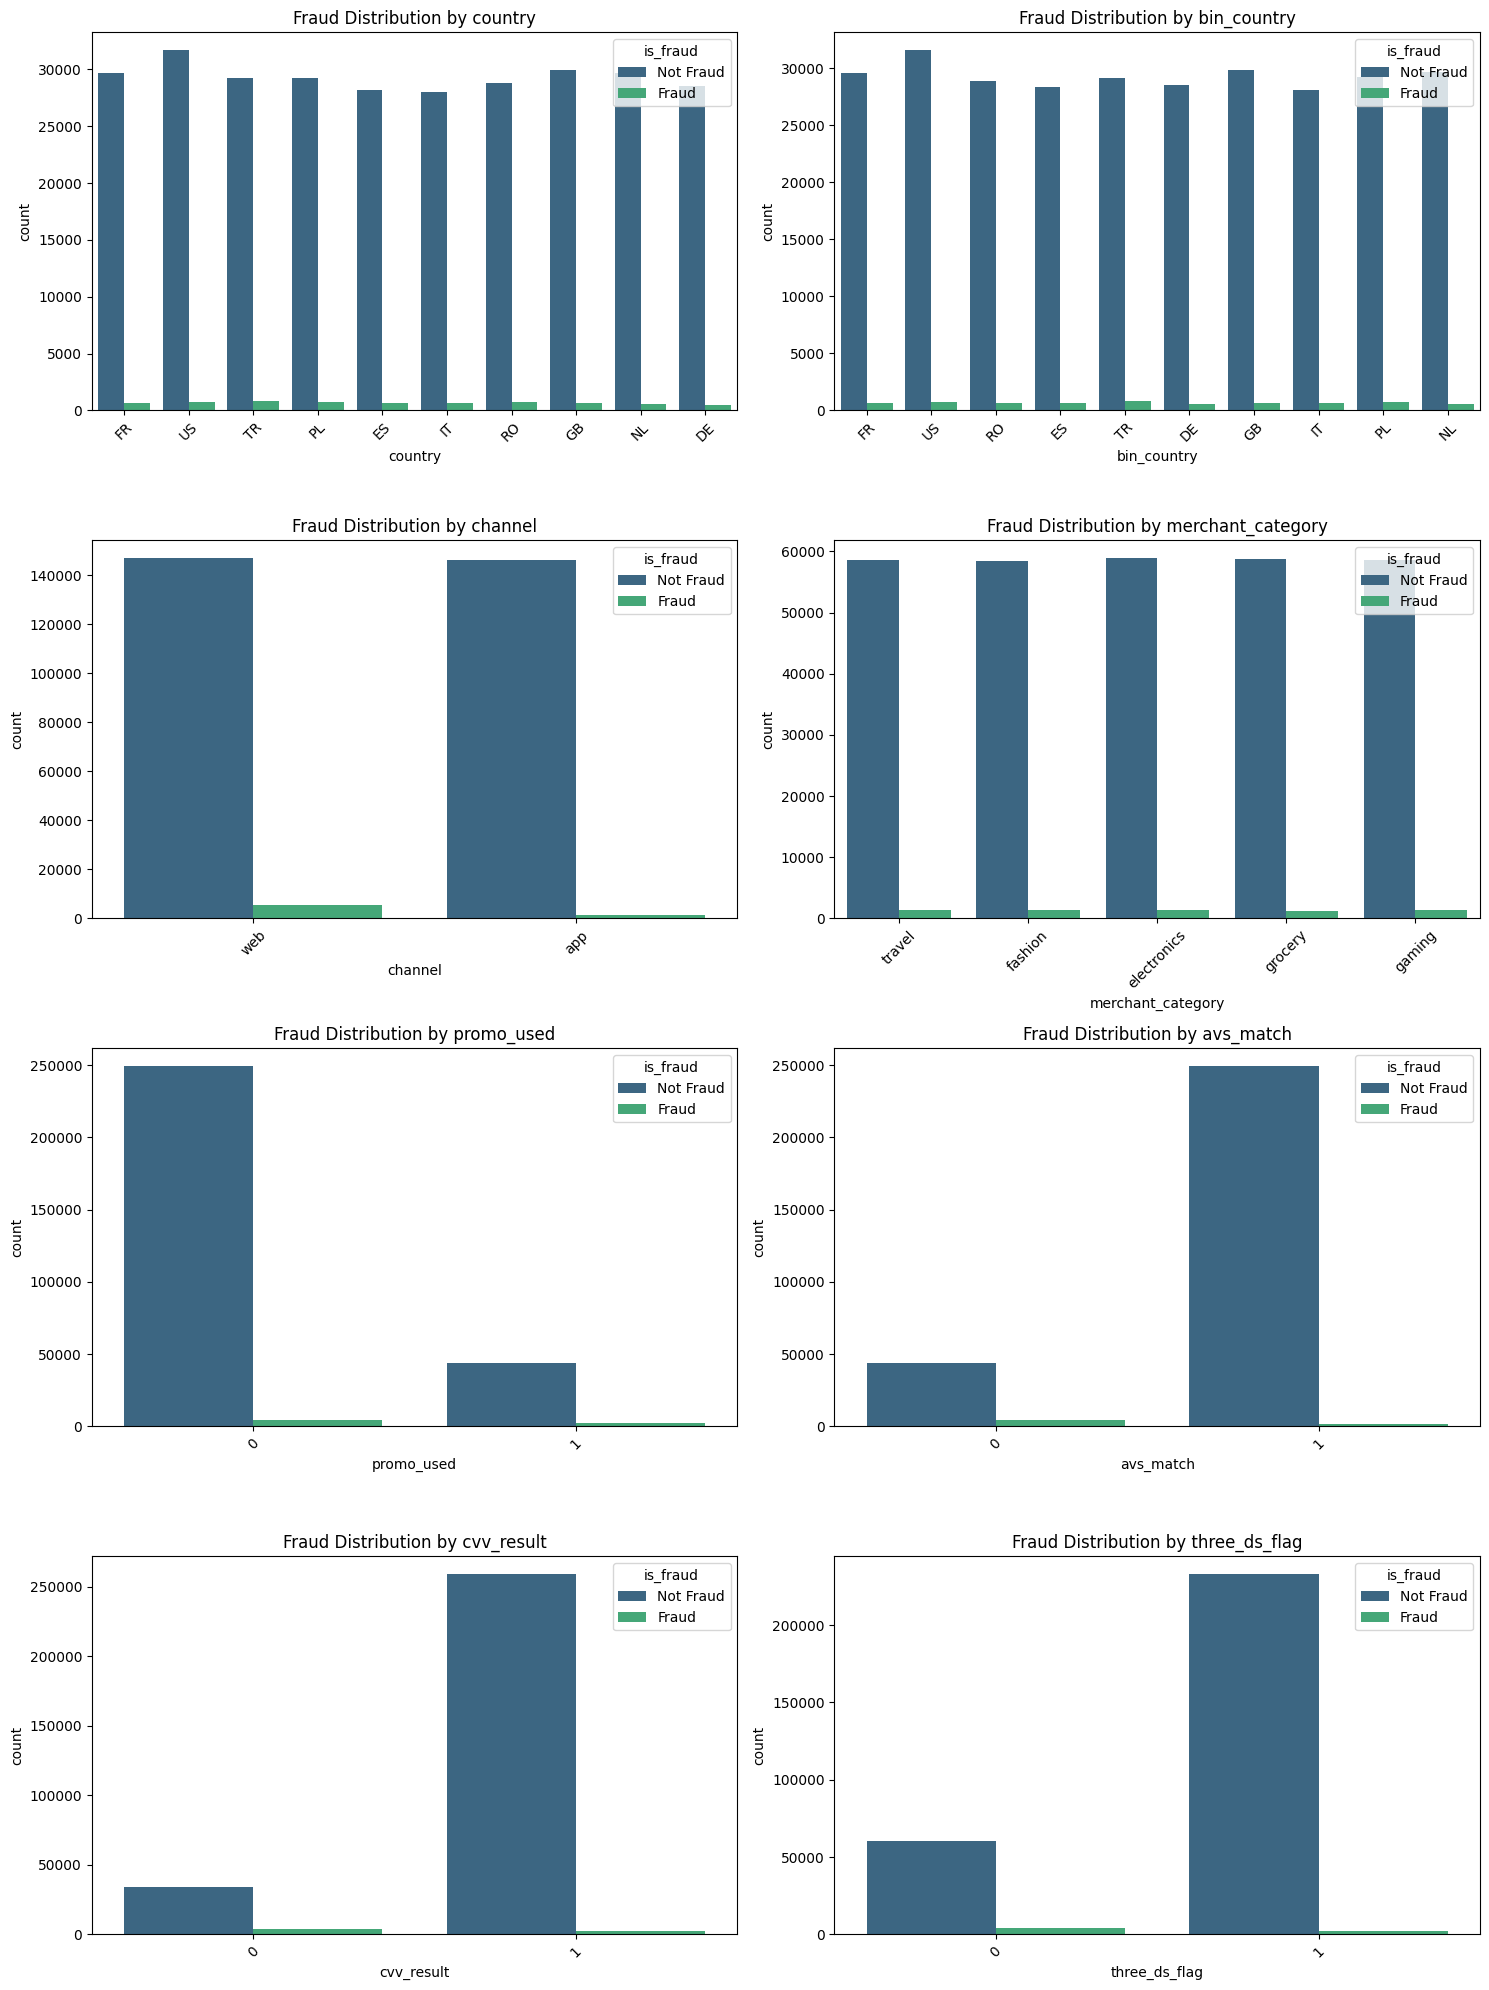

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_fraud_bivariate(df, categorical_cols, target_col='is_fraud'):
    """
    Generates countplots to visualize the relationship between specified
    categorical columns and a binary target variable (e.g., 'is_fraud').

    Args:
        df (pd.DataFrame): The input DataFrame.
        categorical_cols (list): A list of column names to plot.
        target_col (str): The name of the binary target column.
    """
    num_plots = len(categorical_cols)
    num_cols_per_row = 2  # Adjust for desired layout
    num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

    fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, hue=target_col, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Fraud Distribution by {col}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title=target_col, labels=['Not Fraud', 'Fraud'])

    # Turn off any unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Define the categorical columns for bivariate analysis
categorical_features_for_bivariate = ['country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag' ]

# Call the function to generate the plots
plot_categorical_fraud_bivariate(data, categorical_features_for_bivariate, target_col='is_fraud')

### Visualize Fraud Counts in Categorical Features



/tmp/ipython-input-1198087662.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=col, ax=axes[i], palette='magma', order=fraud_data[col].value_counts().index)
/tmp/ipython-input-1198087662.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=col, ax=axes[i], palette='magma', order=fraud_data[col].value_counts().index)
/tmp/ipython-input-1198087662.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=col, ax=axes[i], palette='magma', order=fraud_data[col].value_counts().index)
/

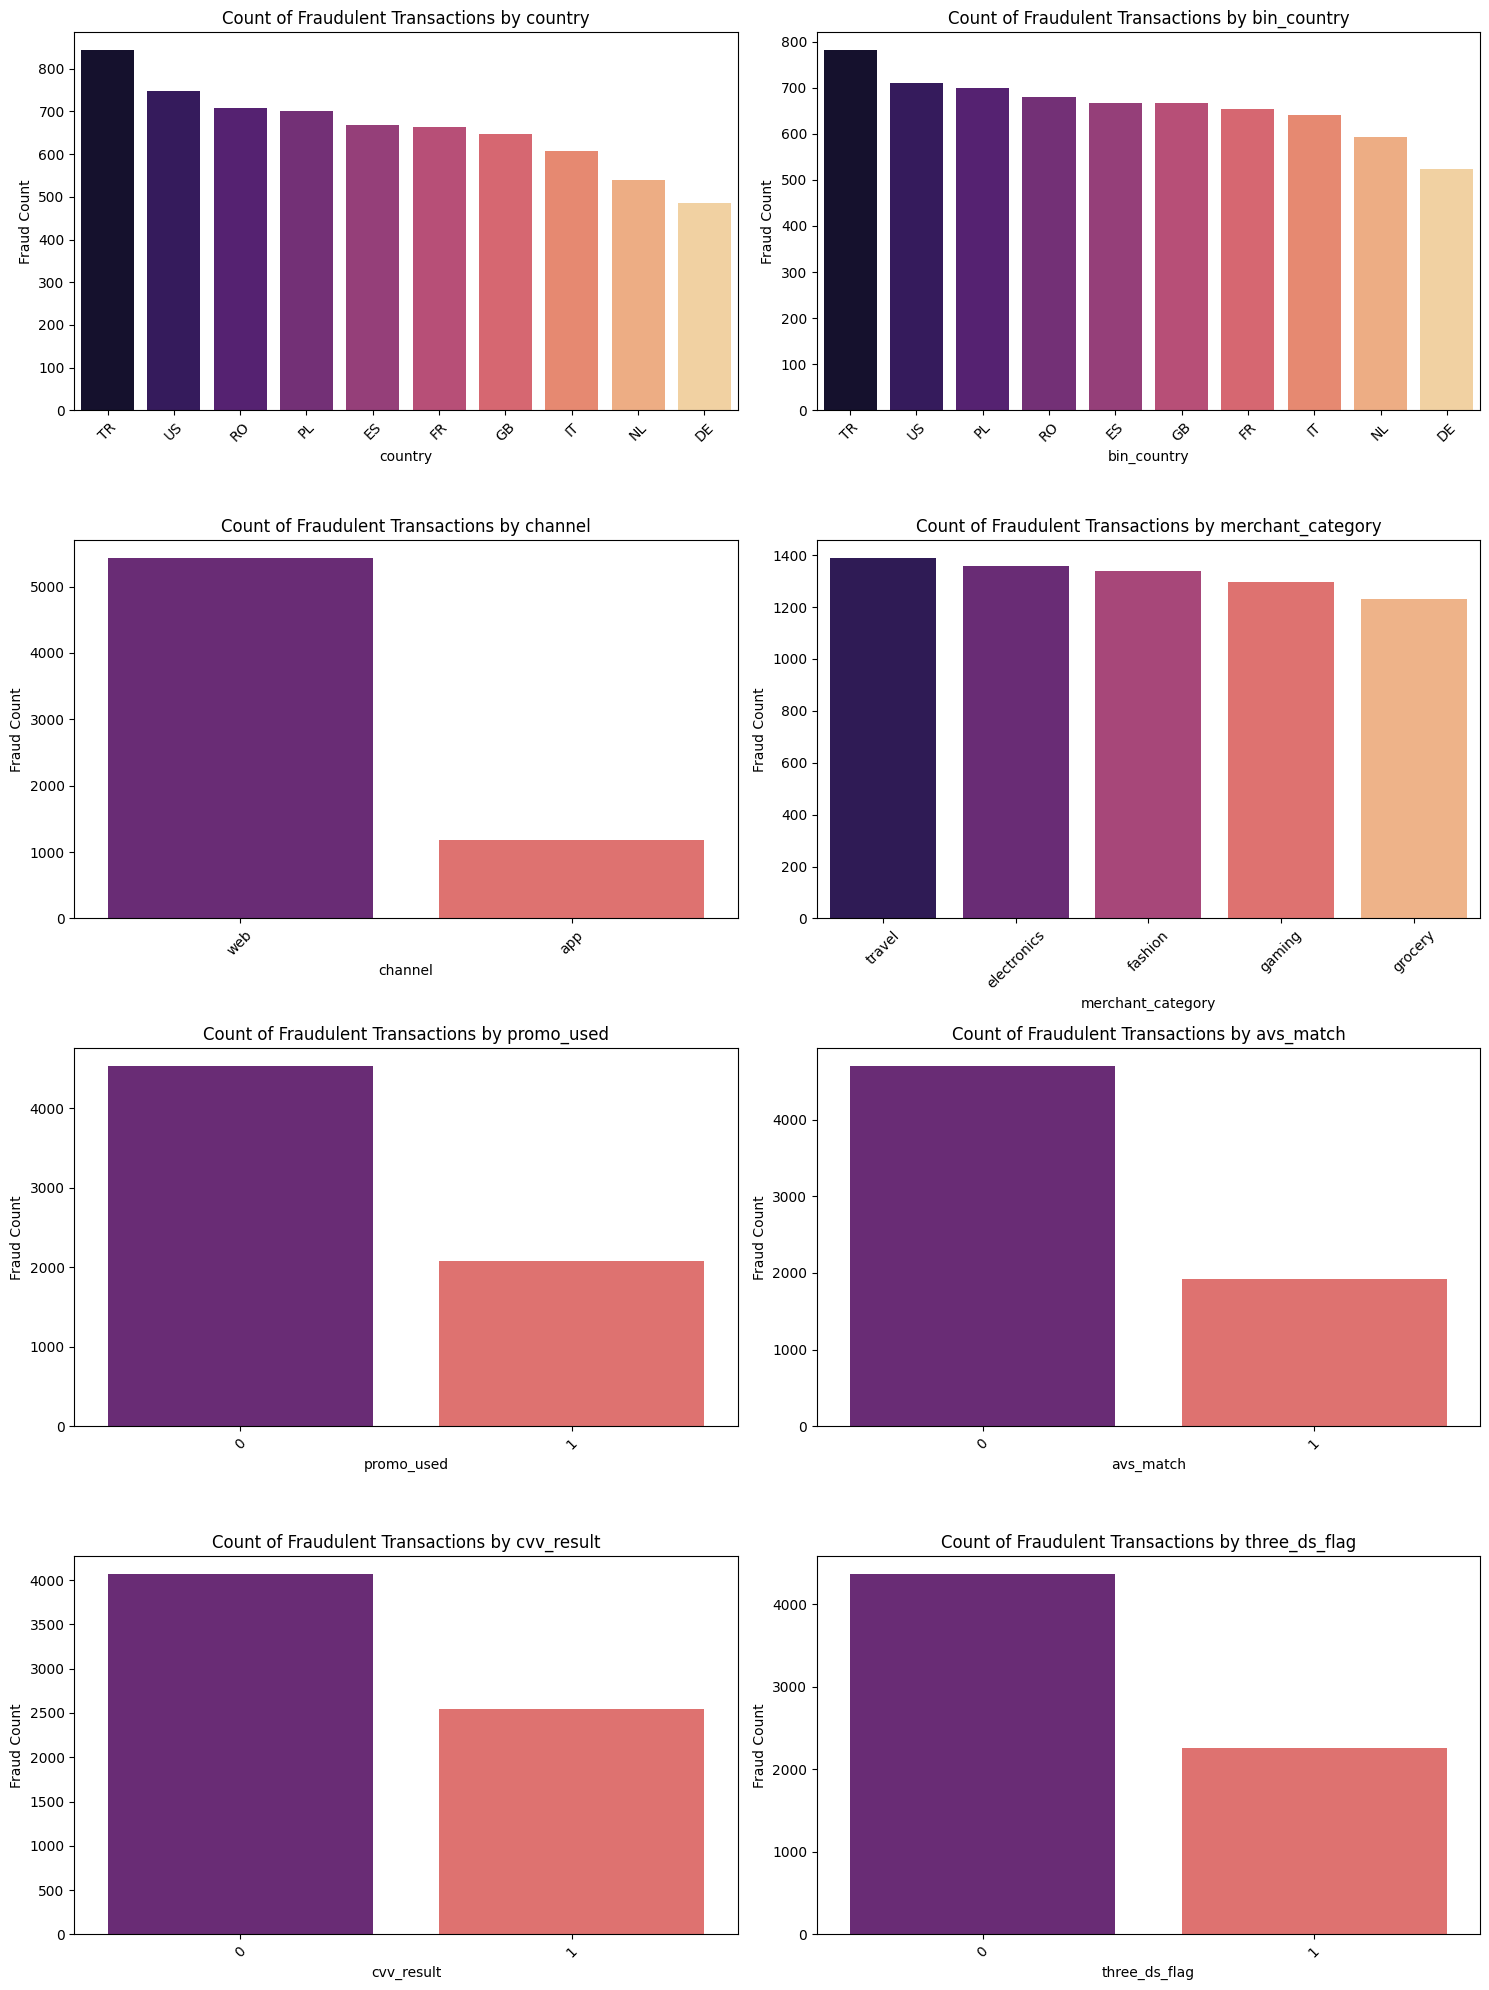

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data to only include fraudulent transactions
fraud_data = data[data['is_fraud'] == 1]

# Define the categorical columns for bivariate analysis
categorical_features_for_bivariate = ['country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag' ]

num_plots = len(categorical_features_for_bivariate)
num_cols_per_row = 2  # Adjust for desired layout
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features_for_bivariate):
    sns.countplot(data=fraud_data, x=col, ax=axes[i], palette='magma', order=fraud_data[col].value_counts().index)
    axes[i].set_title(f'Count of Fraudulent Transactions by {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Fraud Count')

# Turn off any unused subplots
for j in range(num_plots, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

channel = fruad transactions are mostly from website


Clean the data

## Feature Engineering



- Extract transaction_time to hour, day, month
-  convert 'promo_used', 'avs_match', 'cvv_result', and 'three_ds_flag' columns to integer type

In [ ]:
data['transaction_time'] = pd.to_datetime(data['transaction_time'])
data['transaction_hour'] = data['transaction_time'].dt.hour
data['transaction_day_of_week'] = data['transaction_time'].dt.dayofweek
data['transaction_month'] = data['transaction_time'].dt.month

data['promo_used'] = data['promo_used'].astype(int)
data['avs_match'] = data['avs_match'].astype(int)
data['cvv_result'] = data['cvv_result'].astype(int)
data['three_ds_flag'] = data['three_ds_flag'].astype(int)

print("Data types after feature engineering:")
print(data[['transaction_time', 'transaction_hour', 'transaction_day_of_week', 'transaction_month', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']].dtypes)

Data types after feature engineering:
transaction_time           datetime64[ns, UTC]
transaction_hour                         int32
transaction_day_of_week                  int32
transaction_month                        int32
promo_used                               int64
avs_match                                int64
cvv_result                               int64
three_ds_flag                            int64
dtype: object



Apply one-hot encoding to the remaining categorical features: 'country', 'bin_country', 'channel', and 'merchant_category'.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Define categorical columns for one-hot encoding
categorical_cols_to_encode = ['country', 'bin_country', 'channel', 'merchant_category']

# Fit and transform the categorical data
encoded_features = encoder.fit_transform(data[categorical_cols_to_encode])

# Create a DataFrame with the encoded features
encoded_feature_names = encoder.get_feature_names_out(categorical_cols_to_encode)
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=data.index)

# Concatenate the encoded features with the original data
data = pd.concat([data, df_encoded], axis=1)

# Drop the original categorical columns
data.drop(columns=categorical_cols_to_encode, inplace=True)

print("Data shape after one-hot encoding:", data.shape)
print("New columns created:", df_encoded.columns.tolist()[:5], "... and so on")
print("Data types after one-hot encoding:")
print(data[df_encoded.columns].dtypes.head())

Data shape after one-hot encoding: (299695, 43)
New columns created: ['country_DE', 'country_ES', 'country_FR', 'country_GB', 'country_IT'] ... and so on
Data types after one-hot encoding:
country_DE    float64
country_ES    float64
country_FR    float64
country_GB    float64
country_IT    float64
dtype: object


## Data Splitting




In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = data.drop(columns=['is_fraud', 'transaction_id', 'user_id', 'transaction_time'])
y = data['is_fraud']

# Convert y to numeric type if it's still object for stratification
y = y.astype(int)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nClass distribution in y_train (stratified):")
print(y_train.value_counts(normalize=True))

Shape of X_train: (239756, 39)
Shape of X_test: (59939, 39)
Shape of y_train: (239756,)
Shape of y_test: (59939,)

Class distribution in y_train (stratified):
is_fraud
0    0.977936
1    0.022064
Name: proportion, dtype: float64


## Feature Scaling


Apply scaling to numerical features using StandardScaler.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale
numerical_cols_to_scale = [
    'account_age_days',
    'total_transactions_user',
    'avg_amount_user',
    'amount',
    'shipping_distance_km',
    'transaction_hour',
    'transaction_day_of_week',
    'transaction_month'
]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data's numerical features
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Transform both training and testing data's numerical features
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in X_train after scaling (first 5 rows):")
print(X_train[numerical_cols_to_scale].head())


Numerical features in X_train after scaling (first 5 rows):
        account_age_days  total_transactions_user  avg_amount_user    amount  \
138086         -0.256600                 1.559583        -0.031390 -0.142751   
6566           -0.186135                 0.221061        -0.582324 -0.477696   
65697           1.333617                 1.559583        -0.616556 -0.516778   
181023          1.099370                -0.280885        -0.499284 -0.450557   
20468           1.337426                 1.392268         0.175292 -0.136145   

        shipping_distance_km  transaction_hour  transaction_day_of_week  \
138086              0.069564         -0.651796                 1.514960   
6566                0.276488         -0.218525                -1.487415   
65697               0.111043         -0.651796                -1.487415   
181023             -0.343558         -0.362949                 1.514960   
20468               0.026307         -1.229490                -1.487415   

        

Model Training and Evaluation (Logistic Regression)




In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix
import numpy as np

# Initialize Logistic Regression model with class weights
# Using 'balanced' will automatically adjust weights inversely proportional to class frequencies
# Alternatively, if we wanted to use custom weights calculated earlier (e.g., 'weights' array):
# lr_model = LogisticRegression(class_weight={0: weights[0], 1: weights[1]}, solver='liblinear', max_iter=1000, random_state=42)
lr_model = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions on X_test
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model's performance
print("Logistic Regression Model Performance:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Model Performance:

Accuracy: 0.8901
Recall: 0.8533
Precision: 0.1500
F1-score: 0.2551

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     58617
           1       0.15      0.85      0.26      1322

    accuracy                           0.89     59939
   macro avg       0.57      0.87      0.60     59939
weighted avg       0.98      0.89      0.93     59939


Confusion Matrix:
[[52224  6393]
 [  194  1128]]


Model Training and Evaluation (Decision Tree)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Decision Tree classifier with class weights
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on X_test
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model's performance
print("Decision Tree Model Performance:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_dt, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Model Performance:

Accuracy: 0.9868
Recall: 0.6800
Precision: 0.7084
F1-score: 0.6939

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     58617
           1       0.71      0.68      0.69      1322

    accuracy                           0.99     59939
   macro avg       0.85      0.84      0.84     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:
[[58247   370]
 [  423   899]]


Model Training and Evaluation (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Random Forest classifier with class weights
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on X_test
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model's performance
print("Random Forest Model Performance:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model Performance:

Accuracy: 0.9906
Recall: 0.6165
Precision: 0.9357
F1-score: 0.7433

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     58617
           1       0.94      0.62      0.74      1322

    accuracy                           0.99     59939
   macro avg       0.96      0.81      0.87     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:
[[58561    56]
 [  507   815]]


Model Training and Evaluation (XGBoost)


In [ ]:
# handle imbalance data
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=data['is_fraud'])
print(weights)

[ 0.51128008 22.66296128]


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Calculate scale_pos_weight from the previously computed class weights
# weights = [weight_for_class_0, weight_for_class_1]
# scale_pos_weight = count(negative_samples) / count(positive_samples)
# This can be derived as weights[1] / weights[0]
scale_pos_weight_value = weights[1] / weights[0]

# Initialize XGBoost classifier with class weights
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42
    # Removed use_label_encoder=False and eval_metric='logloss' as they are deprecated or default
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on X_test
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model's performance
print("XGBoost Model Performance:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Model Performance:

Accuracy: 0.9737
Recall: 0.8419
Precision: 0.4482
F1-score: 0.5850

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     58617
           1       0.45      0.84      0.59      1322

    accuracy                           0.97     59939
   macro avg       0.72      0.91      0.79     59939
weighted avg       0.98      0.97      0.98     59939


Confusion Matrix:
[[57247  1370]
 [  209  1113]]


## Summarize Model Performance


Compare the performance of all trained models (Logistic Regression, Decision Tree, Random Forest, and XGBoost) using F1-score, Recall, and Precision.


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Create a dictionary to store performance metrics for each model
performance_data = {}

# Logistic Regression metrics
performance_data['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr, pos_label=1),
    'Precision': precision_score(y_test, y_pred_lr, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_lr, pos_label=1)
}

# Decision Tree metrics
performance_data['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt, pos_label=1),
    'Precision': precision_score(y_test, y_pred_dt, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_dt, pos_label=1)
}

# Random Forest metrics
performance_data['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf, pos_label=1),
    'Precision': precision_score(y_test, y_pred_rf, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_rf, pos_label=1)
}

# XGBoost metrics
performance_data['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb, pos_label=1),
    'Precision': precision_score(y_test, y_pred_xgb, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_xgb, pos_label=1)
}

# Create a DataFrame from the performance data
df_performance = pd.DataFrame(performance_data).T

# Display the DataFrame
print("Model Performance Comparison:")
display(df_performance)


Model Performance Comparison:


,Accuracy,Recall,Precision,F1-score
Logistic Regression,0.890105,0.853253,0.149980,0.255117
Decision Tree,0.986770,0.680030,0.708432,0.693941
Random Forest,0.990607,0.616490,0.935706,0.743274
XGBoost,0.973657,0.841906,0.448248,0.585020


# **Re-Splitting data to 75/25**

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = data.drop(columns=['is_fraud', 'transaction_id', 'user_id', 'transaction_time'])
y = data['is_fraud']

# Convert y to numeric type if it's still object for stratification
y = y.astype(int)

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nClass distribution in y_train (stratified):")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test (stratified):")
print(y_test.value_counts(normalize=True))

Shape of X_train: (224771, 39)
Shape of X_test: (74924, 39)
Shape of y_train: (224771,)
Shape of y_test: (74924,)

Class distribution in y_train (stratified):
is_fraud
0    0.977938
1    0.022062
Name: proportion, dtype: float64

Class distribution in y_test (stratified):
is_fraud
0    0.977938
1    0.022062
Name: proportion, dtype: float64


# **Applying SMOTE to training data**

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_train after SMOTE:", X_train_resampled.shape)
print("Shape of y_train after SMOTE:", y_train_resampled.shape)
print("\nClass distribution in y_train after SMOTE:")
print(y_train_resampled.value_counts(normalize=True))

Shape of X_train after SMOTE: (439624, 39)
Shape of y_train after SMOTE: (439624,)

Class distribution in y_train after SMOTE:
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale
numerical_cols_to_scale = [
    'account_age_days',
    'total_transactions_user',
    'avg_amount_user',
    'amount',
    'shipping_distance_km',
    'transaction_hour',
    'transaction_day_of_week',
    'transaction_month'
]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler on the resampled training data's numerical features and transform
X_train_resampled[numerical_cols_to_scale] = scaler.fit_transform(X_train_resampled[numerical_cols_to_scale])

# Transform the testing data's numerical features
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in X_train_resampled after scaling (first 5 rows):")
print(X_train_resampled[numerical_cols_to_scale].head())
print("\nNumerical features in X_test after scaling (first 5 rows):")
print(X_test[numerical_cols_to_scale].head())

Numerical features in X_train_resampled after scaling (first 5 rows):
   account_age_days  total_transactions_user  avg_amount_user    amount  \
0          1.394179                 0.337179         0.181474 -0.384772   
1         -0.185696                -0.925834        -0.581803 -0.445665   
2         -0.500346                -0.023682         0.487673 -0.183624   
3          0.145515                -0.204113        -0.139829 -0.288423   
4         -0.621237                -0.023682        -0.324382 -0.456829   

   shipping_distance_km  transaction_hour  transaction_day_of_week  \
0             -0.750729          0.904305                 0.124642   
1             -0.721426          0.589967                 0.124642   
2             -0.741808          0.432798                -0.971534   
3             -0.685832          1.218642                -0.971534   
4             -0.559341         -1.453230                -0.423446   

   transaction_month  
0           0.658740  
1          -

Logistic after applying SMOTE

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Logistic Regression model without class weights (as imbalance is handled by SMOTE)
lr_model_smote = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# Train the model using SMOTE-resampled data
lr_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on X_test
y_pred_lr_smote = lr_model_smote.predict(X_test)

# Evaluate the model's performance
print("Logistic Regression Model Performance (with SMOTE):\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_smote, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_smote, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr_smote, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_smote))

Logistic Regression Model Performance (with SMOTE):

Accuracy: 0.9224
Recall: 0.7822
Precision: 0.1916
F1-score: 0.3078

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     73271
           1       0.19      0.78      0.31      1653

    accuracy                           0.92     74924
   macro avg       0.59      0.85      0.63     74924
weighted avg       0.98      0.92      0.94     74924


Confusion Matrix:
[[67816  5455]
 [  360  1293]]


Decision Tree with SMOTE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Decision Tree classifier without class weights (as imbalance is handled by SMOTE)
dt_model_smote = DecisionTreeClassifier(random_state=42)

# Train the model using SMOTE-resampled data
dt_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on X_test
y_pred_dt_smote = dt_model_smote.predict(X_test)

# Evaluate the model's performance
print("Decision Tree Model Performance (with SMOTE):\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt_smote, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_smote, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_dt_smote, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_smote))

Decision Tree Model Performance (with SMOTE):

Accuracy: 0.9839
Recall: 0.6818
Precision: 0.6247
F1-score: 0.6520

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73271
           1       0.62      0.68      0.65      1653

    accuracy                           0.98     74924
   macro avg       0.81      0.84      0.82     74924
weighted avg       0.98      0.98      0.98     74924


Confusion Matrix:
[[72594   677]
 [  526  1127]]


Random Forest with SMOTE

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Random Forest classifier without class weights (as imbalance is handled by SMOTE)
rf_model_smote = RandomForestClassifier(random_state=42)

# Train the model using SMOTE-resampled data
rf_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on X_test
y_pred_rf_smote = rf_model_smote.predict(X_test)

# Evaluate the model's performance
print("Random Forest Model Performance (with SMOTE):\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_smote, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_smote, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf_smote, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))

Random Forest Model Performance (with SMOTE):

Accuracy: 0.9897
Recall: 0.6630
Precision: 0.8379
F1-score: 0.7403

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73271
           1       0.84      0.66      0.74      1653

    accuracy                           0.99     74924
   macro avg       0.92      0.83      0.87     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73059   212]
 [  557  1096]]


XGBoost with SMOTE

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize XGBoost classifier without class weights (as imbalance is handled by SMOTE)
xgb_model_smote = XGBClassifier(
    random_state=42
)

# Train the model using SMOTE-resampled data
xgb_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on X_test
y_pred_xgb_smote = xgb_model_smote.predict(X_test)

# Evaluate the model's performance
print("XGBoost Model Performance (with SMOTE):\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_smote, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_smote, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb_smote, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))

XGBoost Model Performance (with SMOTE):

Accuracy: 0.9927
Recall: 0.7598
Precision: 0.8952
F1-score: 0.8220

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     73271
           1       0.90      0.76      0.82      1653

    accuracy                           0.99     74924
   macro avg       0.94      0.88      0.91     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73124   147]
 [  397  1256]]


Summarize Performance after applying SMOTE

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Create a dictionary to store performance metrics for each model
performance_data_smote = {}

# Logistic Regression metrics
performance_data_smote['Logistic Regression (SMOTE)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_smote),
    'Recall': recall_score(y_test, y_pred_lr_smote, pos_label=1),
    'Precision': precision_score(y_test, y_pred_lr_smote, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_lr_smote, pos_label=1)
}

# Decision Tree metrics
performance_data_smote['Decision Tree (SMOTE)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt_smote),
    'Recall': recall_score(y_test, y_pred_dt_smote, pos_label=1),
    'Precision': precision_score(y_test, y_pred_dt_smote, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_dt_smote, pos_label=1)
}

# Random Forest metrics
performance_data_smote['Random Forest (SMOTE)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf_smote),
    'Recall': recall_score(y_test, y_pred_rf_smote, pos_label=1),
    'Precision': precision_score(y_test, y_pred_rf_smote, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_rf_smote, pos_label=1)
}

# XGBoost metrics
performance_data_smote['XGBoost (SMOTE)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb_smote),
    'Recall': recall_score(y_test, y_pred_xgb_smote, pos_label=1),
    'Precision': precision_score(y_test, y_pred_xgb_smote, pos_label=1),
    'F1-score': f1_score(y_test, y_pred_xgb_smote, pos_label=1)
}

# Create a DataFrame from the performance data
df_performance_smote = pd.DataFrame(performance_data_smote).T

# Display the DataFrame
print("Model Performance Comparison (after SMOTE):")
display(df_performance_smote)

Model Performance Comparison (after SMOTE):


,Accuracy,Recall,Precision,F1-score
Logistic Regression (SMOTE),0.922388,0.782214,0.191612,0.30782
Decision Tree (SMOTE),0.983944,0.681791,0.624723,0.65201
Random Forest (SMOTE),0.989736,0.663037,0.837920,0.74029
XGBoost (SMOTE),0.992739,0.759831,0.895225,0.82199


# Prepare Unscaled Data for Tree Models

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features (X) and target variable (y) from the original 'data' DataFrame
# Ensure we are working with the original data before any scaling for this part
X_unscaled = data.drop(columns=['is_fraud', 'transaction_id', 'user_id', 'transaction_time'])
y_unscaled = data['is_fraud'].astype(int) # Convert to int for stratification and SMOTE

# Split data into training and testing sets with stratification
# Using _unscaled suffix to distinguish from previously scaled data
X_train_unscaled, X_test_unscaled, y_train_unscaled, y_test_unscaled = train_test_split(
    X_unscaled, y_unscaled, test_size=0.25, random_state=42, stratify=y_unscaled
)

print("Shape of X_train_unscaled:", X_train_unscaled.shape)
print("Shape of X_test_unscaled:", X_test_unscaled.shape)
print("Shape of y_train_unscaled:", y_train_unscaled.shape)
print("Shape of y_test_unscaled:", y_test_unscaled.shape)
print("\nClass distribution in y_train_unscaled (stratified):")
print(y_train_unscaled.value_counts(normalize=True))

# Initialize SMOTE
smote_unscaled = SMOTE(random_state=42)

# Apply SMOTE to the unscaled training data
X_train_resampled_unscaled, y_train_resampled_unscaled = smote_unscaled.fit_resample(X_train_unscaled, y_train_unscaled)

print("\nShape of X_train_resampled_unscaled after SMOTE:", X_train_resampled_unscaled.shape)
print("Shape of y_train_resampled_unscaled after SMOTE:", y_train_resampled_unscaled.shape)
print("\nClass distribution in y_train_resampled_unscaled after SMOTE:")
print(y_train_resampled_unscaled.value_counts(normalize=True))

Shape of X_train_unscaled: (224771, 39)
Shape of X_test_unscaled: (74924, 39)
Shape of y_train_unscaled: (224771,)
Shape of y_test_unscaled: (74924,)

Class distribution in y_train_unscaled (stratified):
is_fraud
0    0.977938
1    0.022062
Name: proportion, dtype: float64

Shape of X_train_resampled_unscaled after SMOTE: (439624, 39)
Shape of y_train_resampled_unscaled after SMOTE: (439624,)

Class distribution in y_train_resampled_unscaled after SMOTE:
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64


Decision Tree Model (SMOTE, Unscaled)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Decision Tree classifier without class weights (as imbalance is handled by SMOTE)
dt_model_smote_unscaled = DecisionTreeClassifier(random_state=42)

# Train the model using SMOTE-resampled and unscaled data
dt_model_smote_unscaled.fit(X_train_resampled_unscaled, y_train_resampled_unscaled)

# Make predictions on X_test_unscaled
y_pred_dt_smote_unscaled = dt_model_smote_unscaled.predict(X_test_unscaled)

# Evaluate the model's performance
print("Decision Tree Model Performance (with SMOTE, Unscaled):")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_dt_smote_unscaled):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_dt_smote_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_dt_smote_unscaled))

Decision Tree Model Performance (with SMOTE, Unscaled):
Accuracy: 0.9839
Recall: 0.6812
Precision: 0.6245
F1-score: 0.6516

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73271
           1       0.62      0.68      0.65      1653

    accuracy                           0.98     74924
   macro avg       0.81      0.84      0.82     74924
weighted avg       0.98      0.98      0.98     74924


Confusion Matrix:
[[72594   677]
 [  527  1126]]


Random Forest Model (SMOTE, Unscaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Random Forest classifier without class weights (as imbalance is handled by SMOTE)
rf_model_smote_unscaled = RandomForestClassifier(random_state=42)

# Train the model using SMOTE-resampled and unscaled data
rf_model_smote_unscaled.fit(X_train_resampled_unscaled, y_train_resampled_unscaled)

# Make predictions on X_test_unscaled
y_pred_rf_smote_unscaled = rf_model_smote_unscaled.predict(X_test_unscaled)

# Evaluate the model's performance
print("Random Forest Model Performance (with SMOTE, Unscaled):\n")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_rf_smote_unscaled):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_rf_smote_unscaled, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_rf_smote_unscaled, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_rf_smote_unscaled, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_rf_smote_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_rf_smote_unscaled))

Random Forest Model Performance (with SMOTE, Unscaled):

Accuracy: 0.9898
Recall: 0.6630
Precision: 0.8392
F1-score: 0.7408

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73271
           1       0.84      0.66      0.74      1653

    accuracy                           0.99     74924
   macro avg       0.92      0.83      0.87     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73061   210]
 [  557  1096]]


### Confusion Matrix

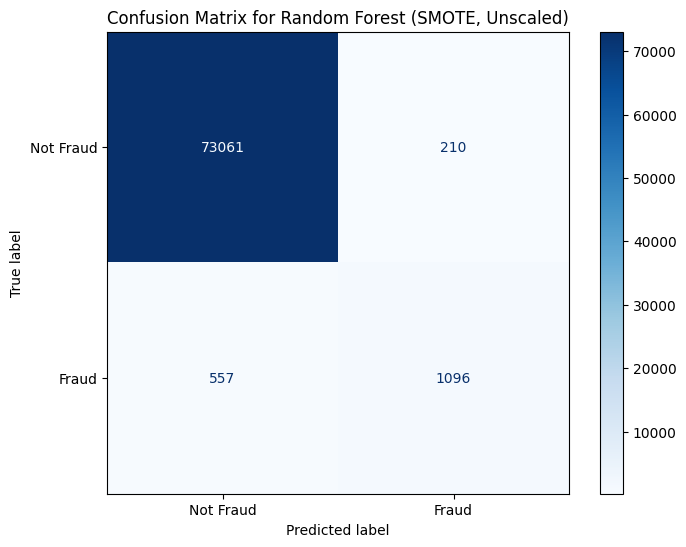

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_unscaled,
    y_pred_rf_smote_unscaled,
    cmap=plt.cm.Blues,
    display_labels=['Not Fraud', 'Fraud'],
    ax=ax
)
ax.set_title('Confusion Matrix for Random Forest (SMOTE, Unscaled)')
plt.show()

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize Decision Tree classifier without class weights (as imbalance is handled by SMOTE)
dt_model_smote_unscaled = DecisionTreeClassifier(random_state=42)

# Train the model using SMOTE-resampled and unscaled data
dt_model_smote_unscaled.fit(X_train_resampled_unscaled, y_train_resampled_unscaled)

# Make predictions on X_test_unscaled
y_pred_dt_smote_unscaled = dt_model_smote_unscaled.predict(X_test_unscaled)

# Evaluate the model's performance
print("Decision Tree Model Performance (with SMOTE, Unscaled):")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_dt_smote_unscaled):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_dt_smote_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_dt_smote_unscaled))

Decision Tree Model Performance (with SMOTE, Unscaled):
Accuracy: 0.9839
Recall: 0.6812
Precision: 0.6245
F1-score: 0.6516

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73271
           1       0.62      0.68      0.65      1653

    accuracy                           0.98     74924
   macro avg       0.81      0.84      0.82     74924
weighted avg       0.98      0.98      0.98     74924


Confusion Matrix:
[[72594   677]
 [  527  1126]]


Train XGBoost Model (SMOTE, Unscaled)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize XGBoost classifier without class weights (as imbalance is handled by SMOTE)
xgb_model_smote_unscaled = XGBClassifier(
    random_state=42
)

# Train the model using SMOTE-resampled and unscaled data
xgb_model_smote_unscaled.fit(X_train_resampled_unscaled, y_train_resampled_unscaled)

# Make predictions on X_test_unscaled
y_pred_xgb_smote_unscaled = xgb_model_smote_unscaled.predict(X_test_unscaled)

# Evaluate the model's performance
print("XGBoost Model Performance (with SMOTE, Unscaled):\n")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_xgb_smote_unscaled):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_xgb_smote_unscaled, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_xgb_smote_unscaled, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_xgb_smote_unscaled, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_xgb_smote_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_xgb_smote_unscaled))

XGBoost Model Performance (with SMOTE, Unscaled):

Accuracy: 0.9927
Recall: 0.7604
Precision: 0.8947
F1-score: 0.8221

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     73271
           1       0.89      0.76      0.82      1653

    accuracy                           0.99     74924
   macro avg       0.94      0.88      0.91     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73123   148]
 [  396  1257]]


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Create a dictionary to store performance metrics for each model
performance_data_smote_unscaled = {}

# Decision Tree metrics (SMOTE, Unscaled)
performance_data_smote_unscaled['Decision Tree (SMOTE, Unscaled)'] = {
    'Accuracy': accuracy_score(y_test_unscaled, y_pred_dt_smote_unscaled),
    'Recall': recall_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1),
    'Precision': precision_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1),
    'F1-score': f1_score(y_test_unscaled, y_pred_dt_smote_unscaled, pos_label=1)
}

# Random Forest metrics (SMOTE, Unscaled)
performance_data_smote_unscaled['Random Forest (SMOTE, Unscaled)'] = {
    'Accuracy': accuracy_score(y_test_unscaled, y_pred_rf_smote_unscaled),
    'Recall': recall_score(y_test_unscaled, y_pred_rf_smote_unscaled, pos_label=1),
    'Precision': precision_score(y_test_unscaled, y_pred_rf_smote_unscaled, pos_label=1),
    'F1-score': f1_score(y_test_unscaled, y_pred_rf_smote_unscaled, pos_label=1)
}

# XGBoost metrics (SMOTE, Unscaled)
performance_data_smote_unscaled['XGBoost (SMOTE, Unscaled)'] = {
    'Accuracy': accuracy_score(y_test_unscaled, y_pred_xgb_smote_unscaled),
    'Recall': recall_score(y_test_unscaled, y_pred_xgb_smote_unscaled, pos_label=1),
    'Precision': precision_score(y_test_unscaled, y_pred_xgb_smote_unscaled, pos_label=1),
    'F1-score': f1_score(y_test_unscaled, y_pred_xgb_smote_unscaled, pos_label=1)
}

# Create a DataFrame from the performance data
df_performance_smote_unscaled = pd.DataFrame(performance_data_smote_unscaled).T

# Display the DataFrame
print("Model Performance Comparison (after SMOTE, Unscaled):")
display(df_performance_smote_unscaled)


Model Performance Comparison (after SMOTE, Unscaled):


,Accuracy,Recall,Precision,F1-score
"Decision Tree (SMOTE, Unscaled)",0.983930,0.681186,0.624515,0.651620
"Random Forest (SMOTE, Unscaled)",0.989763,0.663037,0.839204,0.740791
"XGBoost (SMOTE, Unscaled)",0.992739,0.760436,0.894662,0.822106


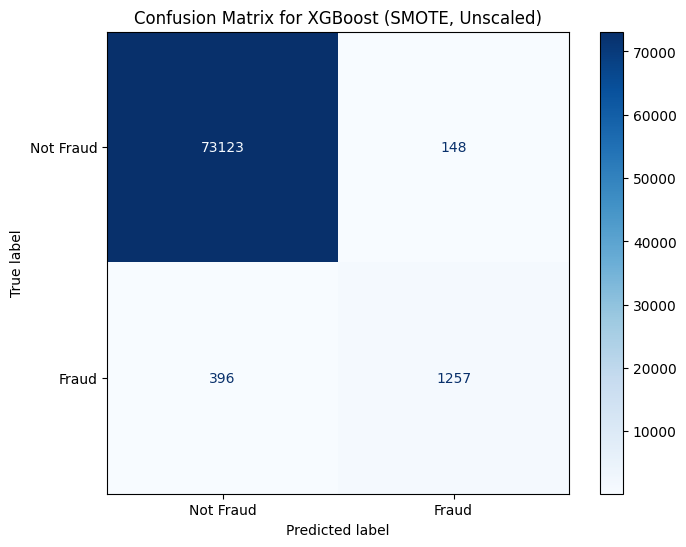

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming xgb_model_smote_unscaled is the desired model and its predictions are y_pred_xgb_smote_unscaled
# and true labels are y_test_unscaled

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_unscaled,
    y_pred_xgb_smote_unscaled,
    cmap=plt.cm.Blues,
    display_labels=['Not Fraud', 'Fraud'],
    ax=ax
)
ax.set_title('Confusion Matrix for XGBoost (SMOTE, Unscaled)')
plt.show()

Hyperparameter Tuning for XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

# Initialize GridSearchCV
grid_search_xgb_unscaled = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), # eval_metric and use_label_encoder to suppress warnings
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the SMOTE-resampled and unscaled training data
grid_search_xgb_unscaled.fit(X_train_resampled_unscaled, y_train_resampled_unscaled)

# Print the best parameters and best score
print("Best parameters found by GridSearchCV for XGBoost (SMOTE, Unscaled):", grid_search_xgb_unscaled.best_params_)
print(f"Best cross-validation F1-score for XGBoost (SMOTE, Unscaled): {grid_search_xgb_unscaled.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:55:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found by GridSearchCV for XGBoost (SMOTE, Unscaled): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best cross-validation F1-score for XGBoost (SMOTE, Unscaled): 0.9936


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Get the best estimator from GridSearchCV
best_xgb_smote_unscaled = grid_search_xgb_unscaled.best_estimator_

# Make predictions on the unscaled test set using the best model
y_pred_best_xgb_smote_unscaled = best_xgb_smote_unscaled.predict(X_test_unscaled)

# Evaluate the model's performance
print("Best Tuned XGBoost Model Performance (with SMOTE, Unscaled):")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_best_xgb_smote_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_best_xgb_smote_unscaled))

# Update the performance comparison DataFrame
performance_data_smote_unscaled['XGBoost (SMOTE, Unscaled, Tuned)'] = {
    'Accuracy': accuracy_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled),
    'Recall': recall_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled, pos_label=1),
    'Precision': precision_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled, pos_label=1),
    'F1-score': f1_score(y_test_unscaled, y_pred_best_xgb_smote_unscaled, pos_label=1)
}

df_performance_smote_unscaled = pd.DataFrame(performance_data_smote_unscaled).T

print("\nUpdated Model Performance Comparison (after SMOTE, Unscaled, including Tuned XGBoost):")
display(df_performance_smote_unscaled)

Best Tuned XGBoost Model Performance (with SMOTE, Unscaled):
Accuracy: 0.9921
Recall: 0.7526
Precision: 0.8724
F1-score: 0.8081

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     73271
           1       0.87      0.75      0.81      1653

    accuracy                           0.99     74924
   macro avg       0.93      0.88      0.90     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73089   182]
 [  409  1244]]

Updated Model Performance Comparison (after SMOTE, Unscaled, including Tuned XGBoost):


,Accuracy,Recall,Precision,F1-score
"Decision Tree (SMOTE, Unscaled)",0.983930,0.681186,0.624515,0.651620
"Random Forest (SMOTE, Unscaled)",0.989763,0.663037,0.839204,0.740791
"XGBoost (SMOTE, Unscaled)",0.992739,0.760436,0.894662,0.822106
"XGBoost (SMOTE, Unscaled, Tuned)",0.992112,0.752571,0.872370,0.808055


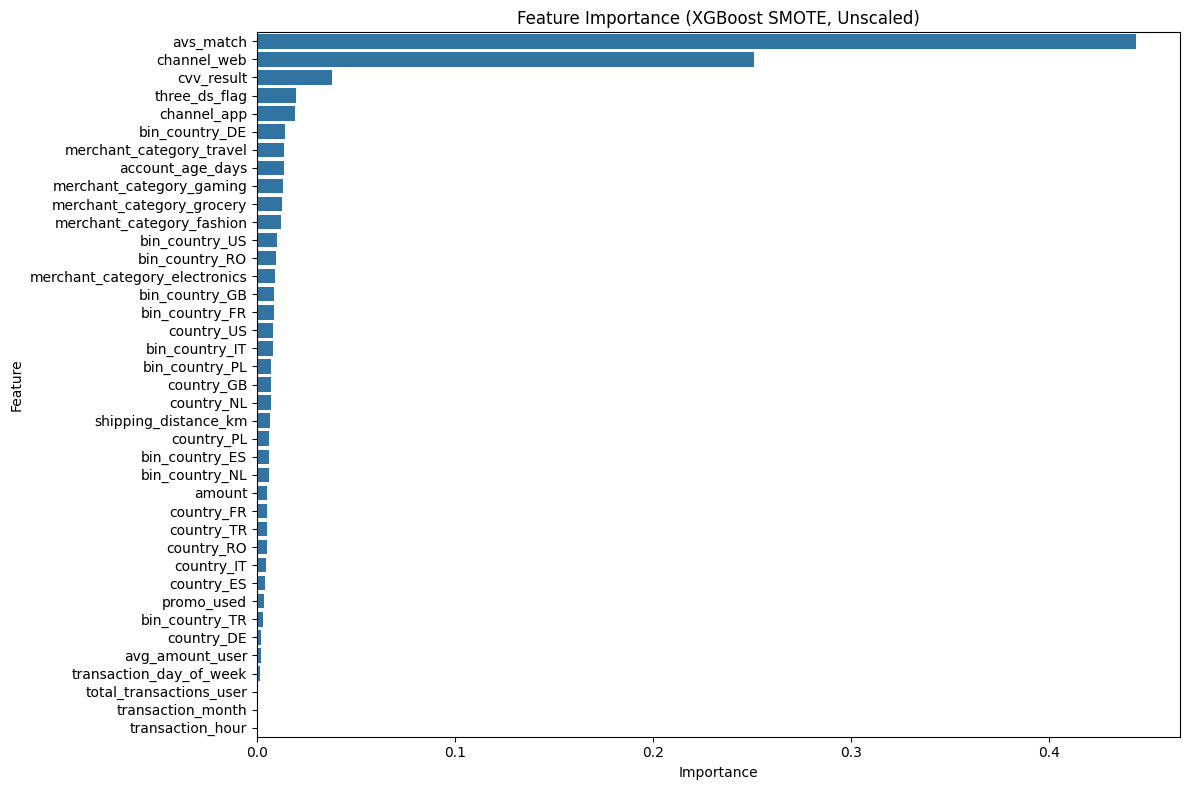

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get feature importances from the best XGBoost model
# Assuming xgb_model_smote_unscaled is the best performing model
feature_importances = xgb_model_smote_unscaled.feature_importances_

# Get feature names from the unscaled training data
feature_names = X_train_resampled_unscaled.columns

# Create a DataFrame for better sorting and visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance (XGBoost SMOTE, Unscaled)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Print Feature Importance

In [ ]:
print(importance_df)

                          Feature  Importance
5                       avs_match    0.443905
33                    channel_web    0.250936
6                      cvv_result    0.037857
7                   three_ds_flag    0.019790
32                    channel_app    0.019192
22                 bin_country_DE    0.014036
38       merchant_category_travel    0.013719
0                account_age_days    0.013412
36       merchant_category_gaming    0.012957
37      merchant_category_grocery    0.012503
35      merchant_category_fashion    0.011882
31                 bin_country_US    0.010256
29                 bin_country_RO    0.009499
34  merchant_category_electronics    0.008840
25                 bin_country_GB    0.008737
24                 bin_country_FR    0.008557
21                     country_US    0.008180
26                 bin_country_IT    0.008100
28                 bin_country_PL    0.007247
15                     country_GB    0.007066
17                     country_NL 

In [ ]:
irrelevant_columns = importance_df[importance_df['Importance'] < 0.002]['Feature'].tolist()
print("Irrelevant columns identified:", irrelevant_columns)

Irrelevant columns identified: ['country_DE', 'avg_amount_user', 'transaction_day_of_week', 'total_transactions_user', 'transaction_month', 'transaction_hour']


Based on the purmutation feature importance, we'll drop some irrelevant column

In [ ]:
X_train_filtered = X_train_resampled_unscaled.drop(columns=irrelevant_columns)
X_test_filtered = X_test_unscaled.drop(columns=irrelevant_columns)

print("Shape of X_train_filtered:", X_train_filtered.shape)
print("Shape of X_test_filtered:", X_test_filtered.shape)

Shape of X_train_filtered: (439624, 33)
Shape of X_test_filtered: (74924, 33)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Initialize XGBoost classifier without class weights (as imbalance is handled by SMOTE)
xgb_model_filtered = XGBClassifier(
    random_state=42
)

# Train the model using filtered, SMOTE-resampled and unscaled data
xgb_model_filtered.fit(X_train_filtered, y_train_resampled_unscaled)

# Make predictions on X_test_filtered
y_pred_xgb_filtered = xgb_model_filtered.predict(X_test_filtered)

# Evaluate the model's performance
print("XGBoost Model Performance (with SMOTE, Filtered, Unscaled):\n")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_xgb_filtered):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_xgb_filtered, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_xgb_filtered, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_xgb_filtered, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_xgb_filtered))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_xgb_filtered))

XGBoost Model Performance (with SMOTE, Filtered, Unscaled):

Accuracy: 0.9912
Recall: 0.7266
Precision: 0.8536
F1-score: 0.7850

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     73271
           1       0.85      0.73      0.78      1653

    accuracy                           0.99     74924
   macro avg       0.92      0.86      0.89     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73065   206]
 [  452  1201]]


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Add the filtered XGBoost model's performance to the dictionary
performance_data_smote_unscaled['XGBoost (SMOTE, Unscaled, Filtered)'] = {
    'Accuracy': accuracy_score(y_test_unscaled, y_pred_xgb_filtered),
    'Recall': recall_score(y_test_unscaled, y_pred_xgb_filtered, pos_label=1),
    'Precision': precision_score(y_test_unscaled, y_pred_xgb_filtered, pos_label=1),
    'F1-score': f1_score(y_test_unscaled, y_pred_xgb_filtered, pos_label=1)
}

# Recreate the DataFrame from the updated performance data dictionary
df_performance_smote_unscaled = pd.DataFrame(performance_data_smote_unscaled).T

# Display the updated DataFrame
print("Updated Model Performance Comparison (after SMOTE, Unscaled, including Filtered XGBoost):")
display(df_performance_smote_unscaled)

Updated Model Performance Comparison (after SMOTE, Unscaled, including Filtered XGBoost):


,Accuracy,Recall,Precision,F1-score
"Decision Tree (SMOTE, Unscaled)",0.983930,0.681186,0.624515,0.651620
"Random Forest (SMOTE, Unscaled)",0.989763,0.663037,0.839204,0.740791
"XGBoost (SMOTE, Unscaled)",0.992739,0.760436,0.894662,0.822106
"XGBoost (SMOTE, Unscaled, Tuned)",0.992112,0.752571,0.872370,0.808055
"XGBoost (SMOTE, Unscaled, Filtered)",0.991218,0.726558,0.853589,0.784967


Fine Tune for Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf_unscaled = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the SMOTE-resampled and unscaled training data
grid_search_rf_unscaled.fit(X_train_resampled_unscaled, y_train_resampled_unscaled)

# Print the best parameters and best score
print("Best parameters found by GridSearchCV for Random Forest (SMOTE, Unscaled):", grid_search_rf_unscaled.best_params_)
print(f"Best cross-validation F1-score for Random Forest (SMOTE, Unscaled): {grid_search_rf_unscaled.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found by GridSearchCV for Random Forest (SMOTE, Unscaled): {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation F1-score for Random Forest (SMOTE, Unscaled): 0.9926


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Get the best estimator from GridSearchCV
best_rf_smote_unscaled = grid_search_rf_unscaled.best_estimator_

# Make predictions on the unscaled test set using the best model
y_pred_best_rf_smote_unscaled = best_rf_smote_unscaled.predict(X_test_unscaled)

# Evaluate the model's performance
print("Best Tuned Random Forest Model Performance (with SMOTE, Unscaled):")
print(f"Accuracy: {accuracy_score(y_test_unscaled, y_pred_best_rf_smote_unscaled):.4f}")
print(f"Recall: {recall_score(y_test_unscaled, y_pred_best_rf_smote_unscaled, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test_unscaled, y_pred_best_rf_smote_unscaled, pos_label=1):.4f}")
print(f"F1-score: {f1_score(y_test_unscaled, y_pred_best_rf_smote_unscaled, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_unscaled, y_pred_best_rf_smote_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_unscaled, y_pred_best_rf_smote_unscaled))

# Update the performance comparison DataFrame
performance_data_smote_unscaled['Random Forest (SMOTE, Unscaled, Tuned)'] = {
    'Accuracy': accuracy_score(y_test_unscaled, y_pred_best_rf_smote_unscaled),
    'Recall': recall_score(y_test_unscaled, y_pred_best_rf_smote_unscaled, pos_label=1),
    'Precision': precision_score(y_test_unscaled, y_pred_best_rf_smote_unscaled, pos_label=1),
    'F1-score': f1_score(y_test_unscaled, y_pred_best_rf_smote_unscaled, pos_label=1)
}

df_performance_smote_unscaled = pd.DataFrame(performance_data_smote_unscaled).T

print("\nUpdated Model Performance Comparison (after SMOTE, Unscaled, including Tuned Random Forest):")
display(df_performance_smote_unscaled)

Best Tuned Random Forest Model Performance (with SMOTE, Unscaled):
Accuracy: 0.9898
Recall: 0.6824
Precision: 0.8240
F1-score: 0.7465

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73271
           1       0.82      0.68      0.75      1653

    accuracy                           0.99     74924
   macro avg       0.91      0.84      0.87     74924
weighted avg       0.99      0.99      0.99     74924


Confusion Matrix:
[[73030   241]
 [  525  1128]]

Updated Model Performance Comparison (after SMOTE, Unscaled, including Tuned Random Forest):


,Accuracy,Recall,Precision,F1-score
"Decision Tree (SMOTE, Unscaled)",0.983930,0.681186,0.624515,0.651620
"Random Forest (SMOTE, Unscaled)",0.989763,0.663037,0.839204,0.740791
"XGBoost (SMOTE, Unscaled)",0.992739,0.760436,0.894662,0.822106
"XGBoost (SMOTE, Unscaled, Tuned)",0.992112,0.752571,0.872370,0.808055
"XGBoost (SMOTE, Unscaled, Filtered)",0.991218,0.726558,0.853589,0.784967
"Random Forest (SMOTE, Unscaled, Tuned)",0.989776,0.682396,0.823959,0.746525


In [ ]:
import pandas as pd

# Combine the performance dataframes for a complete comparison
df_all_performance = pd.concat([df_performance_smote, df_performance_smote_unscaled])

print("\nComprehensive Model Performance Comparison:")
display(df_all_performance)


Comprehensive Model Performance Comparison:


,Accuracy,Recall,Precision,F1-score
Logistic Regression (SMOTE),0.922388,0.782214,0.191612,0.307820
Decision Tree (SMOTE),0.983944,0.681791,0.624723,0.652010
Random Forest (SMOTE),0.989736,0.663037,0.837920,0.740290
XGBoost (SMOTE),0.992739,0.759831,0.895225,0.821990
"Decision Tree (SMOTE, Unscaled)",0.983930,0.681186,0.624515,0.651620
"Random Forest (SMOTE, Unscaled)",0.989763,0.663037,0.839204,0.740791
"XGBoost (SMOTE, Unscaled)",0.992739,0.760436,0.894662,0.822106
"XGBoost (SMOTE, Unscaled, Tuned)",0.992112,0.752571,0.872370,0.808055
"XGBoost (SMOTE, Unscaled, Filtered)",0.991218,0.726558,0.853589,0.784967
"Random Forest (SMOTE, Unscaled, Tuned)",0.989776,0.682396,0.823959,0.746525
